In [4]:
import pandas as pd
import numpy as np

**Zadanie 1**

Stwórz serię danych, której dane to wartości całkowite od 1 do 100, a indeks jest postaci od ean_001 do ean_100.

In [5]:
ean_list = [f" ean_{i:0>3d}" for i in range(1,101)]
data = [i for i in range(1,101)]

pd.Series(data, index=ean_list)

ean_001      1
ean_002      2
ean_003      3
ean_004      4
ean_005      5
          ... 
ean_096     96
ean_097     97
ean_098     98
ean_099     99
ean_100    100
Length: 100, dtype: int64

**Zadanie 2**

Stwórz tablicę numpy o dwóch wymiarach w rozmiarze 10x10, której wartości są zapisane wg. poniższego schematu:
```python
[
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024],
    [3, 9, 27 ... ],
    ...
    [10, 100, 1000, ... ]
]
```
W pierwszej kolumnie znajduje się liczba, która następnie jest w kolejnych kolumnach podnoszona do kwadratu. Zdefiniuj tę tablicę wedle swojego uznania, ale nie jest dopuszczalne wpisanie tych danych "ręcznie".

Stwórz z tych danych ramkę pandas. Kolumny nazwij wg. schematu ['base', 'pow_2', 'pow_3', ..., 'pow_10']


In [6]:
col_names = [f"pow_{i}" for i in range(2, 11)]
col_names.insert(0, "base")

k = []
for i in range(1, 11):
    l = []
    for j in range(1, 11):
        l.append(i**j)
    k.append(l)

array_2d = np.array(k)

df =pd.DataFrame(data=array_2d, columns=col_names)
df


,base,pow_2,pow_3,pow_4,pow_5,pow_6,pow_7,pow_8,pow_9,pow_10
0,1,1,1,1,1,1,1,1,1,1
1,2,4,8,16,32,64,128,256,512,1024
2,3,9,27,81,243,729,2187,6561,19683,59049
3,4,16,64,256,1024,4096,16384,65536,262144,1048576
4,5,25,125,625,3125,15625,78125,390625,1953125,9765625
5,6,36,216,1296,7776,46656,279936,1679616,10077696,60466176
6,7,49,343,2401,16807,117649,823543,5764801,40353607,282475249
7,8,64,512,4096,32768,262144,2097152,16777216,134217728,1073741824
8,9,81,729,6561,59049,531441,4782969,43046721,387420489,3486784401
9,10,100,1000,10000,100000,1000000,10000000,100000000,1000000000,10000000000


**Zadanie 3**

Sprawdź czy tablica numpy z zadania poprzedniego oraz ramka pandas współdzielą ze sobą dane. Jeżeli nie to stwórz kolejną ramkę, która będzie te dane z tablicą współdzieliła (możesz wykorzystać sposób sprawdzenia tego z labów poprzednich).

In [7]:
df.values.base is array_2d #dane współdzielą pamięć

True


**Zadanie 4**

Sprawdź jaki jest przydzielony typ danych w ramce z zadania poprzedniego. Czy można go downcastować do typu, który zapewni zachowanie oryginalnych danych, ale zmniejszy ilość niezbędnej pamięci do ich przechowania? Odpowiedź uzasadnij odnpowienim przykładem w kodzie.

In [8]:
#typ danych
df.dtypes

base      int64
pow_2     int64
pow_3     int64
pow_4     int64
pow_5     int64
pow_6     int64
pow_7     int64
pow_8     int64
pow_9     int64
pow_10    int64
dtype: object

In [9]:
df.astype("int32") #można go downcastować do int32,int16,int8 
#10^10 = 10,000,000,000 > int32: -2,147,483,648 do 2,147,483,647

,base,pow_2,pow_3,pow_4,pow_5,pow_6,pow_7,pow_8,pow_9,pow_10
0,1,1,1,1,1,1,1,1,1,1
1,2,4,8,16,32,64,128,256,512,1024
2,3,9,27,81,243,729,2187,6561,19683,59049
3,4,16,64,256,1024,4096,16384,65536,262144,1048576
4,5,25,125,625,3125,15625,78125,390625,1953125,9765625
5,6,36,216,1296,7776,46656,279936,1679616,10077696,60466176
6,7,49,343,2401,16807,117649,823543,5764801,40353607,282475249
7,8,64,512,4096,32768,262144,2097152,16777216,134217728,1073741824
8,9,81,729,6561,59049,531441,4782969,43046721,387420489,-808182895
9,10,100,1000,10000,100000,1000000,10000000,100000000,1000000000,1410065408


**Zadanie 5**

Wczytaj dane z pliku `iris.data` za pomocą funkcji `read_csv` do zmiennej `iris` jak w przykładzie.

In [10]:
iris =pd.read_csv("iris.data")
iris.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



**Zadanie 6**

Zamień nazwy kolumn w ramce `iris` tak, aby w miejsce spacji wstawić znak `_`. Wyświetl pierwsze 10 wierszy tej ramki.

In [11]:
renamed_columns = ["sepal_length_in_cm", "sepal_width_in_cm", "petal_length_in_cm", "petal_width_in_cm", "class"]
new = dict(zip(iris.columns, renamed_columns))

iris.rename(columns=new, inplace=True)
iris.head(10)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


**Zadanie 7**

Sprawdź metodą `memory_usage()` (z parametrem deep=True oraz bez niego) ile danych zajmuje ramka. Wybierz jeden z typów danych numerycznych rodzaju float o mniejszej precyzji i zapisz ramkę w nowej zmiennej `iris_smaller`, której kolumny numeryczne będą rzutowane na ten nowy typ float. Ponownie sprawdź ile pamięci zostało dla ramki zaalokowane.

In [12]:
iris.memory_usage() # w bajtach

Index                  132
sepal_length_in_cm    1200
sepal_width_in_cm     1200
petal_length_in_cm    1200
petal_width_in_cm     1200
class                 1200
dtype: int64

In [13]:
iris.memory_usage(deep = True)

Index                   132
sepal_length_in_cm     1200
sepal_width_in_cm      1200
petal_length_in_cm     1200
petal_width_in_cm      1200
class                 10550
dtype: int64

In [14]:
iris_smaller = iris.copy()
for column in iris_smaller.columns[:-1]:
    iris_smaller[column] = iris_smaller[column].astype("float32")
    
iris_smaller.memory_usage()

Index                  132
sepal_length_in_cm     600
sepal_width_in_cm      600
petal_length_in_cm     600
petal_width_in_cm      600
class                 1200
dtype: int64

In [15]:
iris_smaller.memory_usage(deep = True)

Index                   132
sepal_length_in_cm      600
sepal_width_in_cm       600
petal_length_in_cm      600
petal_width_in_cm       600
class                 10550
dtype: int64

**Zadanie 8**

Zapisz ramkę do schowka (funkcja `to_clipboard()`), a następnie wklej schowek do edytora tekstowego oraz dowolnego arkusza kalkulacyjnego. Sprawdź format tych danych. 

Teraz skopiuj do schowka część z tych wklejonych danych i zapisz do nowej ramki metodą `from_clipboard()`.
Wyświetl pierwsze 5 wierszy tej ramki.

Rozwiązanie zadania to jedynie wywołanie powyższej funkcji, reszta dla informacji i wiedzy studenta.

In [16]:
a = iris.to_clipboard()

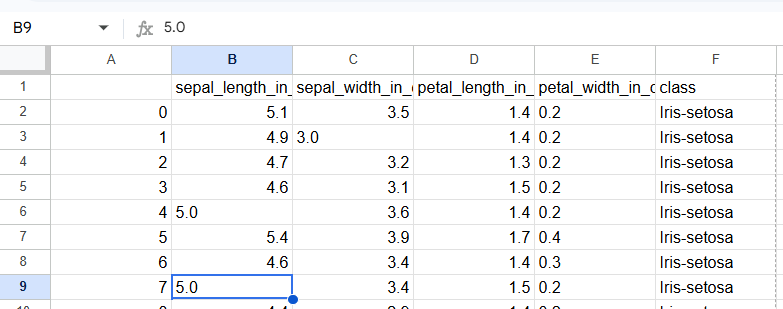

In [17]:
new_df = pd.read_clipboard() #copy - paste table
new_df.head()

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Zadanie 9**

Zapisz ramkę do formatów `parquet`, `json` oraz `pickle` (możliwe, że konieczne będzie doinstalowanie nowych pakietów) korzystając z odpowiednich funkcji opisanych w dokumentacji (link w materiałach).

In [18]:
new_df.to_pickle("df.pkl")

In [19]:
new_df.to_json("df.json")

In [20]:

import pyarrow
print(pyarrow.__version__)

new_df.to_parquet("df.parquet")

24.0.0
